## **Problem Statement**

---



**CUSTOMER SEGMENTAITON**

Use a customer dataset to group customers into different segments based on their
purchasing behavior. Apply clustering techniques like KMeans to identify patterns
and describe the characteristics of each segment. Preprocess the data, perform
clustering, and visualize the results

## Data Source: Kaggle
### Link: [Mall Customer Segmentation Data](https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python)

## Import Required Libraries

In [15]:
# Basic Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Clustering
from sklearn.cluster import KMeans

# Evaluation
from sklearn.metrics import silhouette_score

## Load Dataset

In [16]:
customers_data = pd.read_csv("Mall_Customers.csv")
customers_data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## Data Understanding & Cleaning

In [17]:
customers_data.info()
customers_data.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


## Feature Selection

In [18]:
customer_features = customers_data[['Annual Income (k$)', 'Spending Score (1-100)']]
customer_features.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


## Feature Scaling

In [19]:
scaler = StandardScaler()
scaled_customer_features = scaler.fit_transform(customer_features)

## Elbow Method to Find Optimal K

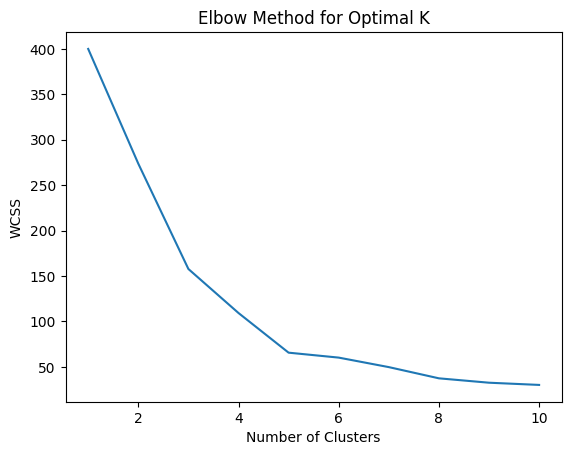

In [20]:
wcss = []

for k in range(1, 11):
    kmeans_model = KMeans(n_clusters=k, random_state=42)
    kmeans_model.fit(scaled_customer_features)
    wcss.append(kmeans_model.inertia_)

plt.figure()
plt.plot(range(1,11), wcss)
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

## Apply KMeans
## KMeans Objective Function

KMeans clustering minimizes the Within-Cluster Sum of Squares (WCSS):

$$
\sum_{i=1}^{k} \sum_{x \in C_i} ||x - \mu_i||^2
$$

Where:
- $k$ = number of clusters  
- $C_i$ = cluster i  
- $\mu_i$ = centroid of cluster i  
- $||x - \mu_i||^2$ = squared Euclidean distance

In [21]:
kmeans_model = KMeans(n_clusters=5, random_state=42)
customer_clusters = kmeans_model.fit_predict(scaled_customer_features)

customers_data['Cluster'] = customer_clusters
customers_data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


## Evaluate Clustering

In [22]:
sil_score = silhouette_score(scaled_customer_features, customer_clusters)
print("Silhouette Score:", sil_score)

Silhouette Score: 0.5546571631111091


## Visualize Customer Segments

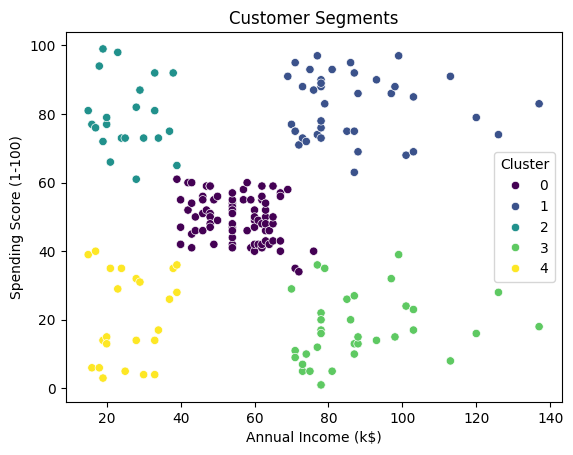

In [23]:
plt.figure()
sns.scatterplot(
    x=customers_data['Annual Income (k$)'],
    y=customers_data['Spending Score (1-100)'],
    hue=customers_data['Cluster'],
    palette='viridis'
)
plt.title("Customer Segments")
plt.show()

Business Interpretation
Cluster Insights:
*  **High Income + High Spending → Premium Customers**

*  **High Income + Low Spending → Careful Customers**

*  **Low Income + High Spending → Impulse Buyers**

*  **Low Income + Low Spending → Budget Customers**

*  **Average → Moderate Customers**